# Color-Magnitude Diagram (CMD) Analysis for A2199

This notebook creates color-magnitude diagrams to analyze galaxy populations in the A2199 cluster.

## Setup and Configuration

Import libraries and set up cosmology (H0=70, ΩM=0.3, ΩΛ=0.7) and plotting parameters.

In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "bold",
    'font.size': 25,
    'font.weight': 'normal',
    
    # Tick direction and appearance
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,            # show top ticks
    'ytick.right': True,          # show right ticks
    'xtick.minor.visible': True,  # show minor x ticks
    'ytick.minor.visible': True,  # show minor y ticks
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    
    # Axes and line properties
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
# Pandas configuration
pd.set_option('display.max_columns', None)

## Load A2199 Data and Apply Extinction Corrections

Load the A2199 master catalog (galaxies within 35 arcmin from cluster center) and apply Galactic extinction corrections to both model and Petrosian magnitudes in all SDSS bands (ugriz).

In [8]:
# Load HeCS-Cluster catalog to retrieve redshift for A2199
hecs_vac_data = pd.read_csv('../../DATA/AllHeCS_VAC_updated.csv')
Z_CLID = hecs_vac_data[hecs_vac_data['CLID'] == 'A2199']['Z'].values[0]

# Load the A2199 galaxy catalog (within 35 arcmin from cluster center)
df0 = pd.read_csv('../../DATA/A2199/A2199_mastercat_within35arcmin.csv')

# Apply Galactic extinction corrections to SDSS model magnitudes
df0['p_modelmag_u_0'] = df0['p_modelmag_u'] - df0['p_extinction_u']
df0['p_modelmag_g_0'] = df0['p_modelmag_g'] - df0['p_extinction_g']
df0['p_modelmag_r_0'] = df0['p_modelmag_r'] - df0['p_extinction_r']
df0['p_modelmag_i_0'] = df0['p_modelmag_i'] - df0['p_extinction_i']
df0['p_modelmag_z_0'] = df0['p_modelmag_z'] - df0['p_extinction_z']

# Apply Galactic extinction corrections to SDSS Petrosian magnitudes
df0['p_petromag_u_0'] = df0['p_petromag_u'] - df0['p_extinction_u']
df0['p_petromag_g_0'] = df0['p_petromag_g'] - df0['p_extinction_g']
df0['p_petromag_r_0'] = df0['p_petromag_r'] - df0['p_extinction_r']
df0['p_petromag_i_0'] = df0['p_petromag_i'] - df0['p_extinction_i']
df0['p_petromag_z_0'] = df0['p_petromag_z'] - df0['p_extinction_z']

# Select only galaxies (not stars) within 35 arcmin for analysis
df = df0[(df0['galaxyflag'] == 1) & (df0['p_radgal'] <= 35)]

## Create Color-Magnitude Diagram (CMD)

Plot the color-magnitude diagram showing:
- Galaxies without spectroscopic redshift (gray)
- Galaxies with spectroscopic redshift (blue)
- Cluster members (red)
- Red sequence fits from literature (Song+2017, Kang+2024, Kang+2025)

Red Sequence (This study): y = (-0.033 +/- 0.004)x + (1.28 +/- 0.07)
Scatter (sigma): 0.065


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_63456/802662251.py:16: SyntaxWarning: invalid escape sequence '\m'
  s=2, color='gray', alpha=0.2, label='no $z_\mathrm{spec}$')
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_63456/802662251.py:20: SyntaxWarning: invalid escape sequence '\m'
  s=4, color='green', alpha=0.6, marker='s', label='$z_\mathrm{spec}$')
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_63456/802662251.py:67: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(blue_members['p_petromag_r_0'],


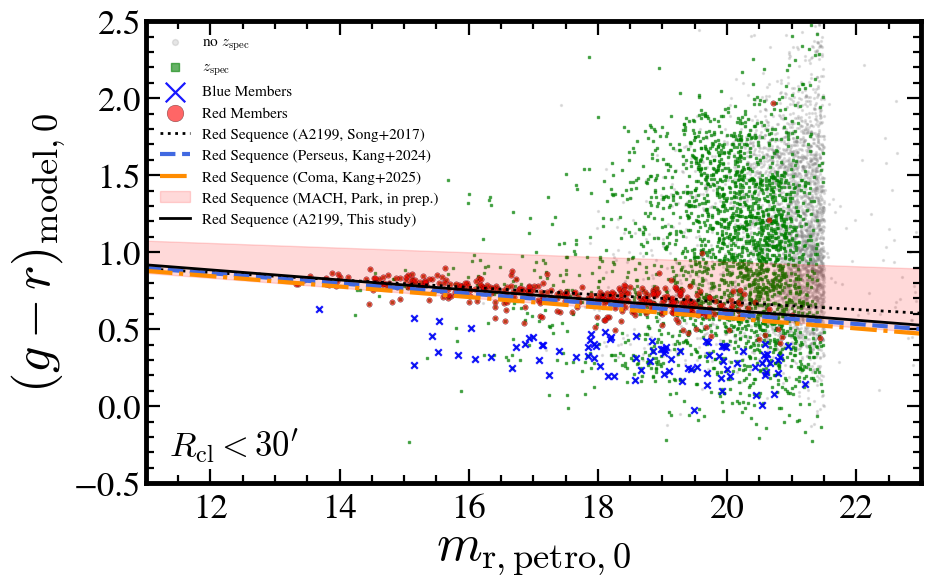

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))  # Larger figure

# --- 1. Masks for full sample ---
mask_no_specz = df['z_tot_z'] == -9
mask_specz = df['z_tot_z'] != -9
mask_member = df['member'] == 'Y'

# --- 2. Plot non-member galaxies (Background/Foreground) ---
ax.scatter(df.loc[mask_no_specz, 'p_petromag_r_0'],
           df.loc[mask_no_specz, 'p_modelmag_g_0'] - df.loc[mask_no_specz, 'p_modelmag_r_0'],
           s=2, color='gray', alpha=0.2, label='no $z_\mathrm{spec}$')

ax.scatter(df.loc[mask_specz, 'p_petromag_r_0'],
           df.loc[mask_specz, 'p_modelmag_g_0'] - df.loc[mask_specz, 'p_modelmag_r_0'],
           s=4, color='green', alpha=0.6, marker='s', label='$z_\mathrm{spec}$')

# --- 3. Red Sequence Fit Using Bright Members Only ---
# Define the "Anchor" sample: Bright, passive members in the cluster core
bright_members = df[
    (df['member'] == 'Y') &
    (df['p_radgal'] <= 30) &
    ((df['p_modelmag_g_0'] - df['p_modelmag_r_0']) > 0.5) &
    (df['p_petromag_r_0'] < 18)
].copy()

# Prepare data for fitting
x_fit = bright_members['p_petromag_r_0']
y_fit = bright_members['p_modelmag_g_0'] - bright_members['p_modelmag_r_0']

# Perform Fit: Degree 1 (Linear). cov=True returns covariance matrix for errors.
p_opt, p_cov = np.polyfit(x_fit, y_fit, 1, cov=True)
slope = p_opt[0]
intercept = p_opt[1]

# Calculate Errors (Square root of diagonal elements of covariance matrix)
perr = np.sqrt(np.diag(p_cov))
slope_err = perr[0]
intercept_err = perr[1]

# Calculate Scatter (Sigma) of the residuals for the bright sample
# Used later to define Red/Blue boundary
y_predict_bright = slope * x_fit + intercept
sigma = np.std(y_fit - y_predict_bright)

# Print the equation with errors to the console
print(f'Red Sequence (This study): y = ({slope:.3f} +/- {slope_err:.3f})x + ({intercept:.2f} +/- {intercept_err:.2f})')
print(f'Scatter (sigma): {sigma:.3f}')

# --- 4. Apply classification to full member sample ---
df_members_all = df[df['member'] == 'Y'].copy()
df_members_all['g_r'] = df_members_all['p_modelmag_g_0'] - df_members_all['p_modelmag_r_0']

# Predict color based on magnitude using our new fit
df_members_all['g_r_pred'] = slope * df_members_all['p_petromag_r_0'] + intercept
df_members_all['residual'] = df_members_all['g_r'] - df_members_all['g_r_pred']

# Classify: Blue members are those > 3 sigma below the fit line
blue_members = df_members_all[df_members_all['residual'] < -3 * sigma]
red_members = df_members_all[df_members_all['residual'] >= -3 * sigma]

# Plot Classified Members
ax.scatter(blue_members['p_petromag_r_0'],
           blue_members['g_r'],
           s=22, color='blue', alpha=0.9, edgecolors='black', linewidths=1.6, marker='x', label='Blue Members')

ax.scatter(red_members['p_petromag_r_0'],
           red_members['g_r'],
           s=16, color='red', alpha=0.6, edgecolors='black', linewidths=0.3, marker='o', label='Red Members')


# --- 5. Plot Reference Red Sequences & This Study ---
x_vals = np.linspace(11, 23, 500)

# 5.1 Song+2018 (Black Dotted)
y_vals_song = 1.156 - 0.024 * x_vals
ax.plot(x_vals, y_vals_song, color='black', linewidth=2.0, ls='dotted', label='Red Sequence (A2199, Song+2017)')

# 5.2 Kang+2024: y = -0.033x + 1.26 (RoyalBlue Dashed)
y_kang24 = 1.26 - 0.033 * x_vals
ax.plot(x_vals, y_kang24, color='royalblue', linewidth=3.0, ls='--', label='Red Sequence (Perseus, Kang+2024)')

# 5.3 Kang+2025: y = -0.034x + 1.253 (DarkOrange Dash-Dot)
y_kang25 = 1.253 - 0.034 * x_vals
ax.plot(x_vals, y_kang25, color='darkorange', linewidth=3.0, ls='-.', label='Red Sequence (Coma, Kang+2025)')

# 5.4 Park+2025 (Red Shaded)
slope_p = -0.0236
intercept_p = 1.23
slope_err_p = 0.0085
intercept_err_p = 0.0113
y_upper_p = (slope_p + slope_err_p) * x_vals + (intercept_p + intercept_err_p)
y_lower_p = (slope_p - slope_err_p) * x_vals + (intercept_p - intercept_err_p)
ax.fill_between(x_vals, y_lower_p, y_upper_p, color='red', alpha=0.15, label='Red Sequence (MACH, Park, in prep.)')

# 5.5 This Study (Black Solid + Shaded Error)
y_vals_this = intercept + slope * x_vals
# Calculate error bands for plotting
y_upper_this = (slope + slope_err) * x_vals + (intercept + intercept_err)
y_lower_this = (slope - slope_err) * x_vals + (intercept - intercept_err)

# Plot line
label_this = fr'Red Sequence (A2199, This study)'  # Simplified label for clarity
ax.plot(x_vals, y_vals_this, color='black', linewidth=2.0, ls='-', label=label_this)
# Plot error shading
# ax.fill_between(x_vals, y_lower_this, y_upper_this, color='black', alpha=0.15)


# --- 6. Plot Formatting ---
ax.set_xlim(11, 23)
ax.set_ylim(-0.5, 2.5)
ax.set_xlabel(r'$m_\mathrm{r,petro, 0}$', fontsize=37.5)
ax.set_ylabel(r'$(g - r)_\mathrm{model, 0}$', fontsize=37.5)
ax.text(0.03, 0.06, r'$R_\mathrm{cl}<30^\prime$', fontsize=25, transform=ax.transAxes)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.minorticks_on()

# Legend
ax.legend(markerscale=3, loc='upper left', fontsize=11, frameon=False, ncol=1)

## Test Different Magnitude Limits on Red Sequence

Test the effect of different r-band magnitude limits on the red sequence selection by comparing member counts at various brightness thresholds.

In [ ]:
import numpy as np
from scipy.stats import linregress

# --- 1. Initial Selection (Fixed r < 18) ---
r_limit = 18
print(f"\n--- Iterative 3-Sigma Clipping Test (r < {r_limit}) ---")

# Updated Header to include Errors
print(f"{'Iter':<5} {'Slope':<9} {'Slope_Err':<10} {'Intercept':<10} {'Int_Err':<10} {'Sigma':<8} {'N_rem':<6} {'N_out'}")
print("-" * 85)

# Create the initial sample dataframe
current_data = df[
    (df['member'] == 'Y') &
    (df['p_radgal'] <= 30) &
    ((df['p_modelmag_g_0'] - df['p_modelmag_r_0']) > 0.5) &
    (df['p_petromag_r_0'] < r_limit)
].copy()

iteration = 0
max_iter = 10  # Safety break

while iteration < max_iter:
    iteration += 1
    
    # 1. Prepare arrays
    X = current_data['p_petromag_r_0'].values
    y = current_data['p_modelmag_g_0'].values - current_data['p_modelmag_r_0'].values
    
    # 2. Perform Linear Fit
    # res contains: slope, intercept, r_value, p_value, stderr (slope error)
    res = linregress(X, y)
    
    # 3. Calculate Intercept Error
    # Try using the attribute (SciPy 1.6+), otherwise calculate manually
    try:
        int_err = res.intercept_stderr
    except AttributeError:
        # Manual calculation: SE_int = SE_slope * sqrt(mean(x^2))
        int_err = res.stderr * np.sqrt(np.mean(X**2))
    
    # 4. Calculate Residuals and Sigma
    y_model = res.slope * X + res.intercept
    residuals = y - y_model
    sigma = np.std(residuals)
    
    # 5. Identify Outliers (> 3 sigma)
    is_outlier = np.abs(residuals) > 3 * sigma
    n_outliers = np.sum(is_outlier)
    
    # 6. Print Results with Errors
    print(f"{iteration:<5} {res.slope:.3f}    {res.stderr:.3f}     {res.intercept:.3f}     {int_err:.3f}     {sigma:.3f}   {len(current_data):<6} {n_outliers}")
    
    # 7. Check for Convergence
    if n_outliers == 0:
        print("-" * 85)
        print("Convergence reached!")
        print(f"Final: y = ({res.slope:.3f} +/- {res.stderr:.3f})x + ({res.intercept:.3f} +/- {int_err:.3f})")
        break
        
    # 8. Update Data (Remove outliers)
    current_data = current_data[~is_outlier].copy()


--- Iterative 3-Sigma Clipping Test (r < 18) ---
Iter  Slope     Slope_Err  Intercept  Int_Err    Sigma    N_rem  N_out
-------------------------------------------------------------------------------------
1     -0.033    0.004     1.277     0.071     0.065   164    3
2     -0.034    0.004     1.303     0.064     0.058   161    3
3     -0.031    0.004     1.261     0.058     0.052   158    1
4     -0.031    0.004     1.256     0.056     0.051   157    0
-------------------------------------------------------------------------------------
Convergence reached!
Final: y = (-0.031 +/- 0.004)x + (1.256 +/- 0.056)
